# Etape 2 - Modelisation thematique

Ce notebook met en oeuvre trois approches de modelisation thematique sur le corpus des professions de foi des legislatives 1993. On commence par la LDA de scikit-learn, qui suit exactement le pipeline presente en cours (CountVectorizer puis LatentDirichletAllocation). On complete avec la NMF (TF-IDF + factorisation matricielle), egalement issue du cours, et enfin avec BERTopic qui exploite des embeddings contextuels multilingues pour depasser les limites du sac de mots.

Pour chaque modele, on calcule la distribution des themes par famille partisane et un indice de specialisation mesurant dans quelle mesure un parti se concentre sur certains sujets plutot que d'autres.

## 0. Imports

In [12]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Pipeline scikit-learn (cours du prof)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Coherence via gensim (metrique Cv recommandee par Roder et al. 2015)
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# pyLDAvis pour la visualisation interactive de la LDA
try:
    import pyLDAvis
    import pyLDAvis.lda_model as pyldavis_sklearn
    PYLDAVIS_OK = True
except ImportError:
    PYLDAVIS_OK = False
    print("pyLDAvis non disponible - section visualisation interactive ignoree")

# BERTopic
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer as CVbert
from sentence_transformers import SentenceTransformer

import spacy

warnings.filterwarnings("ignore")

DATA_DIR    = Path("../data")
PROC_DIR    = DATA_DIR / "processed"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

CORPUS_CSV   = PROC_DIR / "corpus_1993.csv"
TOKENS_JSONL = PROC_DIR / "tokens_1993.jsonl"

print("Corpus CSV   :", CORPUS_CSV.exists())
print("Tokens JSONL :", TOKENS_JSONL.exists())

Corpus CSV   : True
Tokens JSONL : True


## 1. Chargement des donnees

In [13]:
df = pd.read_csv(CORPUS_CSV)
print(f"Documents charges : {len(df):,}")
print(f"Familles partisanes : {df['titulaire-soutien-simplifie'].nunique()}")

# Chargement des tokens lemmatises (produits par le notebook 01)
tokens_map = {}
with open(TOKENS_JSONL, encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        tokens_map[row["id"]] = row["tokens"]

df["tokens"] = df["id"].map(tokens_map)
df = df[df["tokens"].notna()].reset_index(drop=True)

# Le texte pour la LDA est la reunion des lemmes (bag-of-words)
df["text_for_lda"] = df["tokens"].apply(lambda t: " ".join(t))

print(f"Documents avec tokens : {len(df):,}")
print(f"Exemple (50 premiers tokens) : {df['text_for_lda'].iloc[0][:200]}")

Documents charges : 5,835
Familles partisanes : 10
Documents avec tokens : 5,835
Exemple (50 premiers tokens) : election legislative front national français bernard aulagne an marier enfant artisan graveur ornemaniste croix valeur militaire suppleer jacky saude an retraité gendarmerie président ancien gendarme 


## 2. LDA avec scikit-learn

La Latent Dirichlet Allocation est un modele generatif probabiliste dans lequel chaque document est modelise comme un melange de themes latents, et chaque theme comme une distribution sur le vocabulaire (Blei et al., 2003). On suit le pipeline presente en cours : CountVectorizer pour construire la matrice document-termes, puis LatentDirichletAllocation de scikit-learn.

Le nombre de themes K n'est pas appris automatiquement : on le choisit en comparant plusieurs valeurs sur une grille et en retenant celle qui maximise la coherence thematique Cv (Roder et al., 2015), qui est la metrique la mieux correlee avec le jugement humain.

### 2.1 Vectorisation (CountVectorizer)

On construit la matrice document-termes avec CountVectorizer en eliminant les termes trop rares (presents dans moins de 10 documents) et trop frequents (presents dans plus de 60 % du corpus). Ces termes sont soit des hapax sans valeur informationnelle, soit des mots transversaux a tous les partis qui brouillent les structures thematiques.

In [14]:
vectorizer = CountVectorizer(
    max_df=0.60,
    min_df=10,
    max_features=15000,
    ngram_range=(1, 1)
)

dtm = vectorizer.fit_transform(df["text_for_lda"])
vocab = vectorizer.get_feature_names_out()

print(f"Matrice document-termes : {dtm.shape[0]:,} documents x {dtm.shape[1]:,} termes")
print(f"Densite : {dtm.nnz / (dtm.shape[0] * dtm.shape[1]) * 100:.2f}%")

Matrice document-termes : 5,835 documents x 7,542 termes
Densite : 2.61%


### 2.2 Selection du nombre de themes K

On entraine des modeles LDA pour K dans {5, 8, 10, 12, 15} puis on evalue chacun avec la coherence Cv. Cette metrique mesure la co-occurrence des mots representatifs d'un theme dans une fenetre de contexte : un theme avec une coherence elevee est un theme dont les mots apparaissent frequemment ensemble dans les textes, ce qui correspond generalement a un theme interpretable.

On calcule la coherence a partir des 20 mots les plus representatifs de chaque theme, extraits du modele sklearn et evalues par le CoherenceModel de gensim sur les tokens lemmatises.

In [15]:
# Dictionnaire gensim construit a partir des tokens lemmatises (pour la coherence Cv)
tokenized_docs = df["tokens"].tolist()
gensim_dict    = Dictionary(tokenized_docs)

K_VALUES   = [5, 8, 10, 12, 15]
coherences = []
perplexities = []
lda_models   = {}

for k in K_VALUES:
    print(f"  Entrainement LDA K={k}...", end=" ")
    lda = LatentDirichletAllocation(
        n_components=k,
        max_iter=20,
        learning_method="online",
        random_state=42,
        n_jobs=-1
    )
    lda.fit(dtm)
    lda_models[k] = lda

    # Perplexite (critere interne sklearn, plus bas = mieux)
    perp = lda.perplexity(dtm)
    perplexities.append(perp)

    # Coherence Cv : extraction des 20 mots les plus representatifs par theme
    top_words = [
        [vocab[i] for i in topic.argsort()[:-21:-1]]
        for topic in lda.components_
    ]
    cm = CoherenceModel(
        topics=top_words,
        texts=tokenized_docs,
        dictionary=gensim_dict,
        coherence="c_v"
    )
    cv_score = cm.get_coherence()
    coherences.append(cv_score)
    print(f"Cv={cv_score:.4f}  perplexite={perp:.1f}")

best_k = K_VALUES[int(np.argmax(coherences))]
print(f"\nK retenu : {best_k}  (Cv={max(coherences):.4f})")

  Entrainement LDA K=5... Cv=0.4925  perplexite=1230.2
  Entrainement LDA K=8... Cv=0.6274  perplexite=1088.2
  Entrainement LDA K=10... Cv=0.6535  perplexite=1046.9
  Entrainement LDA K=12... Cv=0.6453  perplexite=1011.9
  Entrainement LDA K=15... Cv=0.6016  perplexite=1005.4

K retenu : 10  (Cv=0.6535)


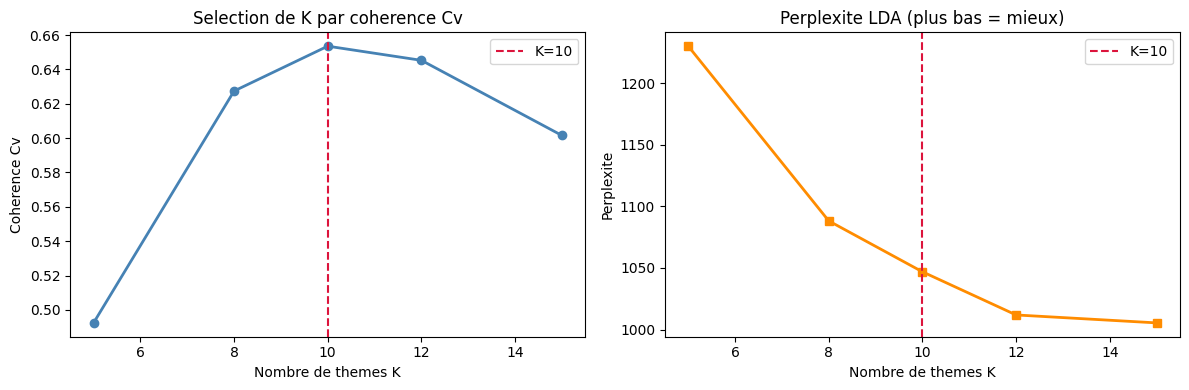

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_VALUES, coherences, "o-", color="steelblue", lw=2)
ax1.axvline(best_k, color="crimson", linestyle="--", label=f"K={best_k}")
ax1.set_xlabel("Nombre de themes K")
ax1.set_ylabel("Coherence Cv")
ax1.set_title("Selection de K par coherence Cv")
ax1.legend()

ax2.plot(K_VALUES, perplexities, "s-", color="darkorange", lw=2)
ax2.axvline(best_k, color="crimson", linestyle="--", label=f"K={best_k}")
ax2.set_xlabel("Nombre de themes K")
ax2.set_ylabel("Perplexite")
ax2.set_title("Perplexite LDA (plus bas = mieux)")
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Modele LDA final

On entraine le modele definitif avec K = best_k themes et 20 iterations. Les themes sont representes par leurs 15 mots les plus importants (poids les plus eleves dans la distribution du theme sur le vocabulaire).

In [17]:
lda_final = lda_models[best_k]

print(f"Modele LDA final : {best_k} themes, 20 iterations\n")
print("-" * 60)
for i, topic in enumerate(lda_final.components_):
    top_words = [vocab[j] for j in topic.argsort()[:-16:-1]]
    print(f"Theme {i:2d} : {' | '.join(top_words)}")
print("-" * 60)

Modele LDA final : 10 themes, 20 iterations

------------------------------------------------------------
Theme  0 : travailleur | patron | payer | entreprise | maintenir | patronat | devoir | vendre | jeter | année | falloir | salaire | sacrifice | dire | bénéfice
Theme  1 : défense | mettre | contre | suppression | famille | création | lutte | populaire | rétablissement | entreprise | priorité | formation | etat | maintien | pro
Theme  2 : falloir | citoyen | pays | droit | non | pouvoir | entreprise | contre | grand | loi | europe | public | temps | européen | retraite
Theme  3 : droite | communiste | gauche | parti | vote | force | vouloir | défendre | progrès | contre | pouvoir | socialiste | avoir | entendre | neuf
Theme  4 : die | der | und | für | den | sie | von | das | eine | mettre | ist | werden | wir | durch | ein
Theme  5 : immigration | immigré | impôt | vouloir | front | rétablir | voix | million | main | sauver | contre | retraite | rien | dire | supprimer
Theme  6 : l

In [18]:
# Attribution d'etiquettes aux themes - a adapter apres inspection
# Les labels ci-dessous sont des suggestions a verifier apres avoir lu les top mots
TOPIC_LABELS = {
    0: "Economie et emploi",
    1: "Environnement et ecologie",
    2: "Securite et immigration",
    3: "Services publics et local",
    4: "Europe et international",
    5: "Gauche et travail",
    6: "Droite et valeurs",
    7: "Jeunesse et education",
    8: "Agriculture et ruralite",
    9: "Democratie et institutions",
    10: "Sante et social",
    11: "Famille et societe",
    12: "Fiscalite et budget",
    13: "Culture et identite",
    14: "Logement et urbanisme",
}
TOPIC_LABELS = {k: v for k, v in TOPIC_LABELS.items() if k < best_k}

print("Labels attribues (a ajuster apres lecture des top mots) :")
for tid, label in TOPIC_LABELS.items():
    top5 = [vocab[j] for j in lda_final.components_[tid].argsort()[:-6:-1]]
    print(f"  [{tid:2d}] {label:<35} : {', '.join(top5)}")

Labels attribues (a ajuster apres lecture des top mots) :
  [ 0] Economie et emploi                  : travailleur, patron, payer, entreprise, maintenir
  [ 1] Environnement et ecologie           : défense, mettre, contre, suppression, famille
  [ 2] Securite et immigration             : falloir, citoyen, pays, droit, non
  [ 3] Services publics et local           : droite, communiste, gauche, parti, vote
  [ 4] Europe et international             : die, der, und, für, den
  [ 5] Gauche et travail                   : immigration, immigré, impôt, vouloir, front
  [ 6] Droite et valeurs                   : loi, naturel, programme, parti, nature
  [ 7] Jeunesse et education               : maire, député, conseiller, jean, vie
  [ 8] Agriculture et ruralite             : écologie, vert, écologiste, entente, ecologiste
  [ 9] Democratie et institutions          : nature, animal, rassemblement, nom, bulletin


### 2.4 Distribution des themes par document

In [19]:
# Vecteurs de distributions theta_d (probabilites de chaque theme pour chaque document)
doc_topic_matrix = lda_final.transform(dtm)

# Stocker dans le dataframe
for i in range(best_k):
    df[f"lda_topic_{i}"] = doc_topic_matrix[:, i]

df["lda_dominant_topic"] = doc_topic_matrix.argmax(axis=1)
df["lda_dominant_label"] = df["lda_dominant_topic"].map(TOPIC_LABELS)

print("Distribution du theme dominant :")
print(df["lda_dominant_label"].value_counts().to_string())

Distribution du theme dominant :
lda_dominant_label
Jeunesse et education         2431
Securite et immigration        749
Services publics et local      548
Agriculture et ruralite        538
Gauche et travail              527
Democratie et institutions     466
Economie et emploi             235
Europe et international        189
Droite et valeurs               96
Environnement et ecologie       56


### 2.5 Visualisation interactive : pyLDAvis

pyLDAvis permet d'explorer interactivement les themes LDA. Chaque bulle correspond a un theme, positionnee selon les distances inter-themes reduites en 2D. La taille de la bulle est proportionnelle au poids global du theme dans le corpus. En selectionnant une bulle, on voit les termes les plus representatifs du theme (barre rouge) comparativement a leur frequence dans le corpus (barre grise).

In [20]:
if PYLDAVIS_OK:
    pyLDAvis.enable_notebook()
    panel = pyldavis_sklearn.prepare(
        lda_final, dtm, vectorizer,
        mds="tsne", sort_topics=False
    )
    pyLDAvis.save_html(panel, str(FIGURES_DIR / "02_lda_vis.html"))
    print("Visualisation pyLDAvis sauvegardee :", FIGURES_DIR / "02_lda_vis.html")
    pyLDAvis.display(panel)
else:
    print("pyLDAvis non disponible. Installer avec : pip install pyldavis")

Visualisation pyLDAvis sauvegardee : ../figures/02_lda_vis.html


### 2.6 Specialisation thematique par parti

Pour chaque famille partisane, on calcule la distribution moyenne des themes puis un indice de specialisation defini comme le ratio entre la proportion d'un theme dans un parti et sa proportion dans le corpus global. Un indice superieur a 1 indique une sur-representation, inferieur a 1 une sous-representation.

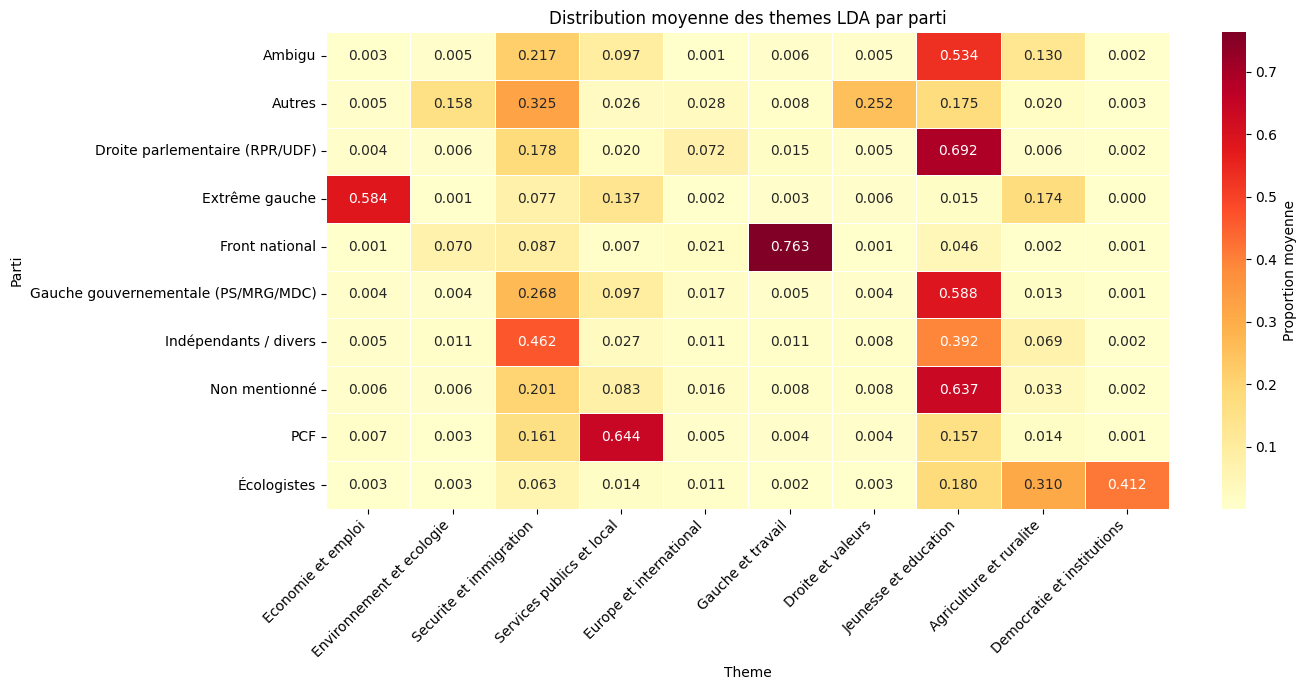

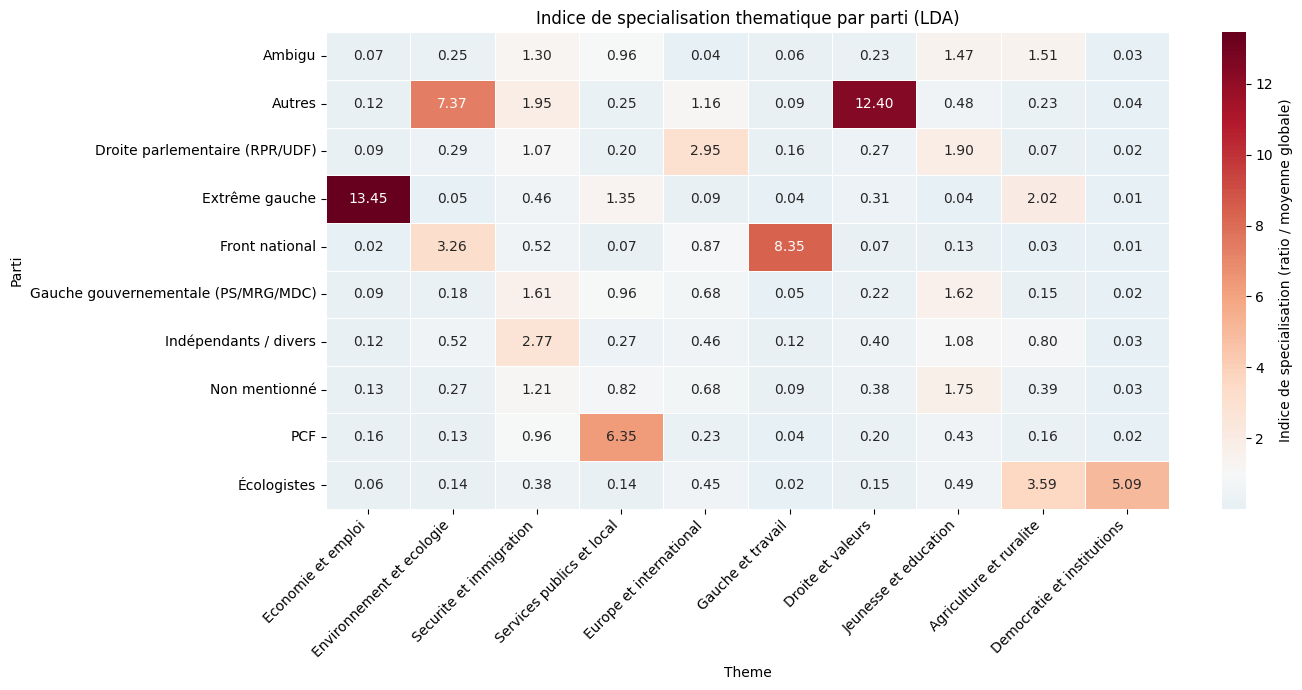

In [21]:
topic_cols = [f"lda_topic_{i}" for i in range(best_k)]
labels_list = [TOPIC_LABELS.get(i, f"Theme_{i}") for i in range(best_k)]

# Distribution moyenne par parti
parti_topic = (
    df.groupby("titulaire-soutien-simplifie")[topic_cols]
    .mean()
    .rename(columns={f"lda_topic_{i}": TOPIC_LABELS.get(i, f"Theme_{i}") for i in range(best_k)})
)

# Indice de specialisation
global_dist = df[topic_cols].mean().values
spec_matrix = parti_topic.values / (global_dist + 1e-9)
df_spec     = pd.DataFrame(spec_matrix, index=parti_topic.index, columns=labels_list)

# Figure 1 : distribution moyenne
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    parti_topic, cmap="YlOrRd", ax=ax, linewidths=0.4,
    cbar_kws={"label": "Proportion moyenne"}, fmt=".3f", annot=True
)
ax.set_title("Distribution moyenne des themes LDA par parti")
ax.set_xlabel("Theme")
ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_topic_by_parti.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2 : specialisation
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    df_spec, cmap="RdBu_r", center=1.0, ax=ax, linewidths=0.4,
    cbar_kws={"label": "Indice de specialisation (ratio / moyenne globale)"},
    fmt=".2f", annot=True
)
ax.set_title("Indice de specialisation thematique par parti (LDA)")
ax.set_xlabel("Theme")
ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_specialisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. NMF (Non-negative Matrix Factorization)

La NMF est une alternative a la LDA presentee en cours. Au lieu du modele probabiliste de Blei, elle factorise la matrice TF-IDF V (n documents x m termes) en deux matrices non negatives : W (n x K, les poids des themes par document) et H (K x m, les mots par theme). Cette approche tend a produire des themes plus nets et plus distincts que la LDA, au prix d'une interpretabilite probabiliste moindre.

On utilise le meme K que pour la LDA, et on compare les structures thematiques obtenues.

### 3.1 Vectorisation TF-IDF

La NMF s'applique sur la matrice TF-IDF (et non les simples comptages), ce qui pondere les termes par leur specificite dans le corpus.

In [22]:
tfidf = TfidfVectorizer(
    max_df=0.60,
    min_df=10,
    max_features=15000,
    ngram_range=(1, 1)
)

tfidf_matrix = tfidf.fit_transform(df["text_for_lda"])
vocab_tfidf  = tfidf.get_feature_names_out()

print(f"Matrice TF-IDF : {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} termes")

Matrice TF-IDF : 5,835 documents x 7,542 termes


### 3.2 Modele NMF

In [23]:
nmf_model = NMF(
    n_components=best_k,
    random_state=42,
    max_iter=200,
    init="nndsvda"
)

W_nmf = nmf_model.fit_transform(tfidf_matrix)   # poids des themes par document
H_nmf = nmf_model.components_                    # mots par theme

print(f"NMF entraine : {best_k} themes, erreur de reconstruction = {nmf_model.reconstruction_err_:.2f}\n")
print("-" * 60)
for i, topic in enumerate(H_nmf):
    top_words = [vocab_tfidf[j] for j in topic.argsort()[:-16:-1]]
    print(f"Theme NMF {i:2d} : {' | '.join(top_words)}")
print("-" * 60)

NMF entraine : 10 themes, erreur de reconstruction = 62.48

------------------------------------------------------------
Theme NMF  0 : immigré | immigration | rétablir | front | impôt | carte | sauver | voix | supprimer | main | million | vouloir | dire | rien | nationalité
Theme NMF  1 : animal | nature | rassemblement | existence | nom | bulletin | ecologiste | activité | documenta | ruffi | corrida | minimun | vivisection | feuille | compléte
Theme NMF  2 : communiste | droite | vote | parti | neuf | force | dirigeant | gauche | progrès | entendre | opposer | servir | voix | défendre | actuel
Theme NMF  3 : patron | payer | patronat | travailleur | maintenir | jeter | sacrifice | bourgeoisie | bénéfice | vendre | banque | entreprise | devoir | année | employé
Theme NMF  4 : écologie | entente | ecologiste | vert | ecologie | écologiste | generation | vie | génération | environnement | humain | chance | assemblée | réconcilier | planète
Theme NMF  5 : union | maire | député | généra

### 3.3 Specialisation partisane NMF

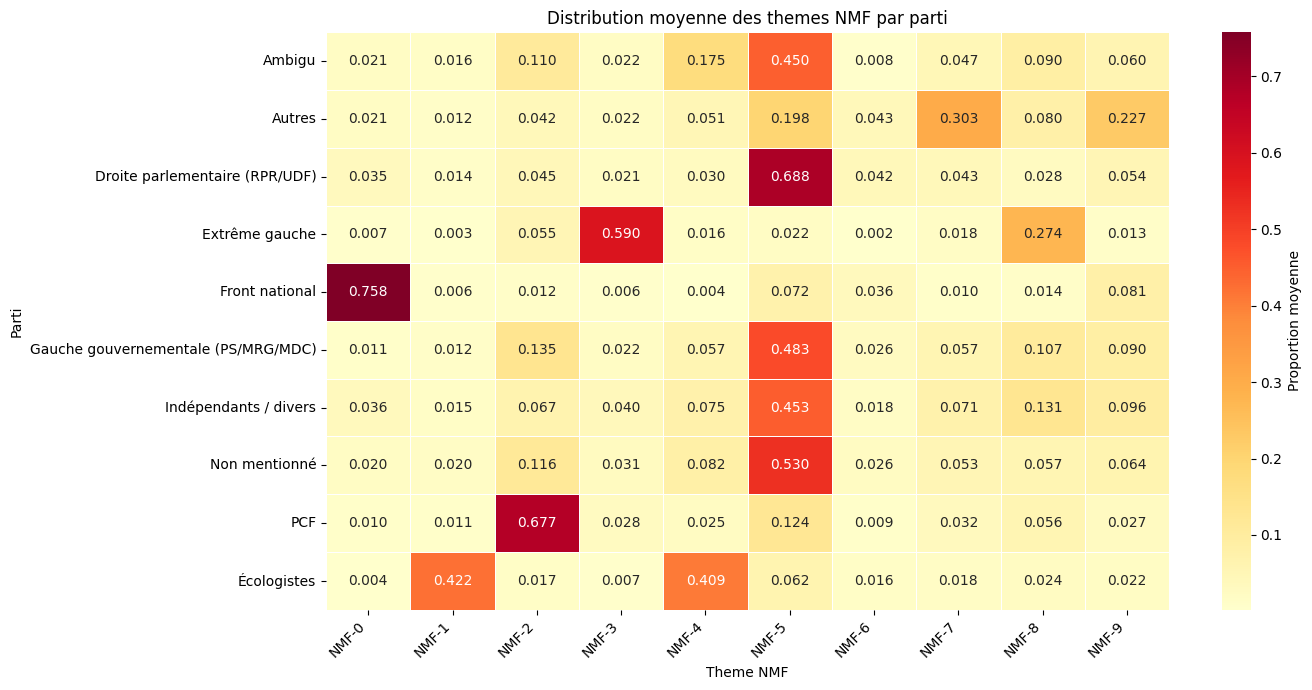

In [24]:
# Normaliser W_nmf pour obtenir des distributions (somme = 1 par document)
W_nmf_norm = W_nmf / (W_nmf.sum(axis=1, keepdims=True) + 1e-9)

for i in range(best_k):
    df[f"nmf_topic_{i}"] = W_nmf_norm[:, i]

nmf_cols = [f"nmf_topic_{i}" for i in range(best_k)]
nmf_labels_list = [f"NMF-{i}" for i in range(best_k)]

parti_nmf = (
    df.groupby("titulaire-soutien-simplifie")[nmf_cols]
    .mean()
    .rename(columns={f"nmf_topic_{i}": f"NMF-{i}" for i in range(best_k)})
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    parti_nmf, cmap="YlOrRd", ax=ax, linewidths=0.4,
    cbar_kws={"label": "Proportion moyenne"}, fmt=".3f", annot=True
)
ax.set_title("Distribution moyenne des themes NMF par parti")
ax.set_xlabel("Theme NMF")
ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_nmf_topic_by_parti.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. BERTopic

BERTopic s'appuie sur une architecture radicalement differente des deux modeles precedents. Plutot que de travailler sur des vecteurs bag-of-words, il encode chaque document dans un espace semantique dense de 384 dimensions via un modele de type BERT multilingue (paraphrase-multilingual-MiniLM-L12-v2). Ces embeddings capturent le sens contextuel des mots - le meme mot peut avoir des representations tres differentes selon le contexte - la ou la LDA et la NMF traitent chaque occurrence de maniere identique.

Le pipeline complet comprend : calcul des embeddings (SentenceTransformer), reduction de dimensionnalite (UMAP, 5 dimensions), clustering non supervise (HDBSCAN), puis representation des themes par les termes les plus specifiques de chaque cluster via TF-IDF par classe. Cette approche est particulierement adaptee a notre corpus de textes OCR, car les embeddings encodent la semantique au-dela de la forme exacte des mots, ce qui les rend moins sensibles aux coquilles de transcription.

### 4.1 Calcul des embeddings

Les embeddings sont calcules sur les textes nettoys mais non lemmatises (clean_text_embeddings), afin de preserver les informations syntaxiques que le modele BERT a appris a exploiter. Le calcul prend environ 15 secondes sur GPU et 3 minutes sur CPU. Les embeddings sont mis en cache pour eviter de les recalculer a chaque execution.

In [25]:
EMB_FILE = PROC_DIR / "embeddings_1993.npy"
docs_emb = df["clean_text_embeddings"].tolist()

if EMB_FILE.exists():
    embeddings = np.load(EMB_FILE)
    print(f"Embeddings charges depuis le cache : {embeddings.shape}")
else:
    # Remplacer device='cuda' par 'cpu' si pas de GPU
    embedding_model = SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        device="cpu"
    )
    embeddings = embedding_model.encode(
        docs_emb,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMB_FILE, embeddings)
    print(f"Embeddings calcules et sauvegardes : {embeddings.shape}")

Batches: 100%|██████████| 92/92 [02:36<00:00,  1.70s/it]

Embeddings calcules et sauvegardes : (5835, 384)


### 4.2 Pipeline BERTopic

In [26]:
nlp = spacy.load("fr_core_news_md")
stop_words_fr = list(nlp.Defaults.stop_words) + [
    "france", "francais", "francaise",
    "circonscription", "elections", "election", "legislatives",
    "mars", "ans", "candidat", "candidats", "suppleant", "suppleante",
    "votez", "voter", "vu", "madame", "monsieur", "mademoiselle",
    "notre", "nos", "votre", "vos", "politique", "pays",
    "po", "fonds", "cevipof", "cevipov",
]

umap_model = UMAP(
    n_neighbors=15, n_components=5,
    min_dist=0.0, metric="cosine",
    random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=80, min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
vectorizer_bert = CVbert(
    stop_words=stop_words_fr,
    ngram_range=(1, 2),
    min_df=3, max_df=0.70
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_bert,
    min_topic_size=80,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs_emb, embeddings)

topic_info = topic_model.get_topic_info()
print(f"\nNombre de themes detectes : {len(topic_info) - 1}  (hors bruit -1)")
print(f"Documents non classes (-1) : {(np.array(topics) == -1).sum()}")
topic_info.head(15)

2026-04-27 13:00:55,330 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-27 13:01:29,027 - BERTopic - Dimensionality - Completed ✓
2026-04-27 13:01:29,029 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-27 13:01:29,418 - BERTopic - Cluster - Completed ✓
2026-04-27 13:01:29,423 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-27 13:01:33,619 - BERTopic - Representation - Completed ✓



Nombre de themes detectes : 5  (hors bruit -1)
Documents non classes (-1) : 309


,Topic,Count,Name,Representation,Representative_Docs
0,-1,309,-1_travailleurs_animaux_nature animaux_rassemb...,"[travailleurs, animaux, nature animaux, rassem...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
1,0,4230,0_franais_rpr_udf_jean,"[franais, rpr, udf, jean, national, gauche, im...",[ELECTIONS LEGISLATIVES DES ET MARS 2ème CIRCO...
2,1,807,1_cologie_entente_verts_generation,"[cologie, entente, verts, generation, humain, ...",[République Française Elections Législatives M...
3,2,221,2_animaux_nature animaux_rassemblement nature_...,"[animaux, nature animaux, rassemblement nature...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
4,3,185,3_patrons_travailleurs_patronat_maintenir emplois,"[patrons, travailleurs, patronat, maintenir em...",[Elections législatives du mars Pourquoi voter...
5,4,83,4_loi naturelle_naturelle_fonde_cohrence,"[loi naturelle, naturelle, fonde, cohrence, co...",[ELECTIONS LEGISLATIVES MARS Votre candidat du...


### 4.3 Reduction et visualisations

In [27]:
# Reduction a un nombre de themes comparable a la LDA pour faciliter la comparaison
N_TOPICS_FINAL = best_k
topic_model.reduce_topics(docs_emb, nr_topics=N_TOPICS_FINAL)
topics_reduced = topic_model.topics_

topic_info_r = topic_model.get_topic_info()
print(f"Themes apres reduction : {len(topic_info_r) - 1}")
topic_info_r

2026-04-27 13:01:34,410 - BERTopic - Topic reduction - Reducing number of topics
2026-04-27 13:01:34,411 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(6).
2026-04-27 13:01:34,411 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-27 13:01:38,500 - BERTopic - Representation - Completed ✓


Themes apres reduction : 5


,Topic,Count,Name,Representation,Representative_Docs
0,-1,309,-1_travailleurs_animaux_nature animaux_rassemb...,"[travailleurs, animaux, nature animaux, rassem...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
1,0,4230,0_franais_rpr_udf_jean,"[franais, rpr, udf, jean, national, gauche, im...",[ELECTIONS LEGISLATIVES DES ET MARS 2ème CIRCO...
2,1,807,1_cologie_entente_verts_generation,"[cologie, entente, verts, generation, humain, ...",[République Française Elections Législatives M...
3,2,221,2_animaux_nature animaux_rassemblement nature_...,"[animaux, nature animaux, rassemblement nature...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
4,3,185,3_patrons_travailleurs_patronat_maintenir emplois,"[patrons, travailleurs, patronat, maintenir em...",[Elections législatives du mars Pourquoi voter...
5,4,83,4_loi naturelle_naturelle_fonde_cohrence,"[loi naturelle, naturelle, fonde, cohrence, co...",[ELECTIONS LEGISLATIVES MARS Votre candidat du...


In [ ]:
# Barchart des mots representatifs par theme
fig_bar = topic_model.visualize_barchart(top_n_topics=N_TOPICS_FINAL, n_words=8, height=700)
fig_bar.write_html(str(FIGURES_DIR / "02_bertopic_barchart.html"))
fig_bar.show()

# Carte des distances inter-themes
fig_map = topic_model.visualize_topics()
fig_map.write_html(str(FIGURES_DIR / "02_bertopic_intertopic_map.html"))
fig_map.show()

### 4.4 Distribution des themes BERTopic par parti

In [ ]:
df["bertopic"] = topics_reduced

# Noms courts : 3 mots representatifs par theme
bt_names = {
    row["Topic"]: " / ".join(row["Representation"][:3])
    for _, row in topic_model.get_topic_info().iterrows()
    if row["Topic"] != -1
}
df["bertopic_label"] = df["bertopic"].map(bt_names).fillna("bruit")

# Distribution par parti (hors documents non classes)
df_bt = df[df["bertopic"] != -1].copy()
bt_dist = (
    df_bt.groupby(["titulaire-soutien-simplifie", "bertopic_label"])
    .size().unstack(fill_value=0)
)
bt_dist_pct = bt_dist.div(bt_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    bt_dist_pct, cmap="Blues", ax=ax, linewidths=0.3,
    cbar_kws={"label": "Proportion"},
    fmt=".2f", annot=True
)
ax.set_title("Distribution des themes BERTopic par parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_bertopic_by_parti.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Synthese comparative

Les trois modeles repondent a la meme question - quels sont les themes du corpus ? - mais depuis des angles differents.

La LDA (bag-of-words, modele probabiliste) et la NMF (bag-of-words, factorisation matricielle) partagent la meme representation des textes. La LDA produit des distributions douces sur les themes alors que la NMF tend a des affectations plus nettes. Dans les deux cas, les themes sont decrits par une liste de mots et chaque document est decrit par une distribution sur K themes.

BERTopic travaille differemment : les documents sont representes dans un espace semantique continu, les themes emergent de clusters dans cet espace, et le bruit (documents non classifiables) est explicitement modelise. Cette approche est plus flexible mais les themes ne sont pas des distributions de probabilite : chaque document appartient a un seul cluster.

In [ ]:
print("Recapitulatif")
print("-" * 55)
print(f"LDA  : {best_k} themes, coherence Cv = {max(coherences):.4f}")
print(f"NMF  : {best_k} themes, erreur = {nmf_model.reconstruction_err_:.2f}")
print(f"BERT : {len(topic_info_r)-1} themes, {(np.array(topics_reduced)==-1).sum()} docs non classes")
print("-" * 55)

## 6. Sauvegarde

In [ ]:
COLS_OUT = (
    ["id", "titulaire-soutien-simplifie", "titulaire-sexe",
     "lda_dominant_topic", "lda_dominant_label",
     "bertopic", "bertopic_label"]
    + [f"lda_topic_{i}" for i in range(best_k)]
    + [f"nmf_topic_{i}" for i in range(best_k)]
)

df[COLS_OUT].to_csv(PROC_DIR / "topics_1993.csv", index=False)
print("Sauvegarde :", PROC_DIR / "topics_1993.csv")

# Modele BERTopic
topic_model.save(str(PROC_DIR / "bertopic_model_1993"))
print("Modele BERTopic sauvegarde :", PROC_DIR / "bertopic_model_1993")